In [1]:
!nvidia-smi

Mon Dec  2 22:28:33 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
# Install ultralytics for YOLOv8
!pip install ultralytics==8.0.20

# Install albumentations for augmentation support
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.2/261.2 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.6 MB/s eta 0:00:00


In [3]:
import zipfile
import os

# Define the path of the uploaded zip file
dataset_zip = "/content/Chess Pieces.v23-raw.yolov8.zip"
dataset_path = "/content/dataset"

# Extract the zip file
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(dataset_path)

print("Dataset extracted to:", dataset_path)

Dataset extracted to: /content/dataset


In [4]:
# Walk through the dataset directory and print its structure
for dirpath, dirnames, filenames in os.walk(dataset_path):
    print(f"Directory: {dirpath}")
    for file_name in filenames[:5]:  # Display only the first 5 files in each directory
        print(f"  File: {file_name}")

Directory: /content/dataset
  File: README.dataset.txt
  File: README.roboflow.txt
  File: data.yaml
Directory: /content/dataset/valid
Directory: /content/dataset/valid/images
  File: 6a41b6c8201604216ad196f842c6a2c6_jpg.rf.465cabf5502d8514f08087f183c3cb2a.jpg
  File: 424d6506342fa2471e71586675ed092c_jpg.rf.43baba77beb2f5588d5cc05ee7c081ec.jpg
  File: aec1aa6773dbbe004554f405cdef2bea_jpg.rf.748dcb4e54783f3bceb3c341d9eee5f1.jpg
  File: IMG_0319_JPG.rf.4ebd9c3d828dfa381411157d7b4ad4da.jpg
  File: e53bf8a0e692a4ccd5f1dc2bc19e7751_jpg.rf.181fa15089d35840f7c13edd8e22b1f5.jpg
Directory: /content/dataset/valid/labels
  File: 7e97f49e613a59a70b833e4c0b2c1c04_jpg.rf.e3d8cc08e136002cec4bf8350be37c47.txt
  File: 6a41b6c8201604216ad196f842c6a2c6_jpg.rf.465cabf5502d8514f08087f183c3cb2a.txt
  File: d4f7caf01359b9a757c930140f746fad_jpg.rf.2b5cb1a63d242e69953a94e870bf8624.txt
  File: c20ca9283ea51ac7707905894a7da703_jpg.rf.d23d9f998440d64312d949fdcdfa1b7d.txt
  File: d3b9309d00a2b671407b918ea867a935_j

In [8]:
# Open and read the contents of the data.yaml file
yaml_path = "/content/dataset/data.yaml"

with open(yaml_path, 'r') as file:
    print(file.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']

roboflow:
  workspace: joseph-nelson
  project: chess-pieces-new
  version: 23
  license: Public Domain
  url: https://universe.roboflow.com/joseph-nelson/chess-pieces-new/dataset/23


In [10]:
# Fix paths in data.yaml
correct_yaml_content = f"""
train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images

nc: 13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']
"""

# Write the corrected content back to the data.yaml file
with open(yaml_path, 'w') as file:
    file.write(correct_yaml_content)

print("Updated data.yaml with correct paths:")
print(correct_yaml_content)

Updated data.yaml with correct paths:

train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images

nc: 13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']



In [11]:
results = model.train(data=yaml_path,  # Path to fixed data.yaml
                      epochs=50,      # Number of epochs
                      imgsz=640,      # Image size
                      batch=16,       # Batch size
                      name="chess_yolov8_model",  # Model name for saved runs
                      plots=True)     # Generate plots during training

Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
yolo/engine/trainer: task=detect, mode=train, model=yolov8s.yaml, data=/content/dataset/data.yaml, epochs=50, patience=50, batch=16, imgsz=640, save=True, cache=False, device=, workers=8, project=None, name=chess_yolov8_model, exist_ok=False, pretrained=False, optimizer=SGD, verbose=False, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, overlap_mask=True, mask_ratio=4, dropout=False, val=True, save_json=False, save_hybrid=False, conf=0.001, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=ultralytics/assets/, show=False, save_txt=False, save_conf=False, save_crop=False, hide_labels=False, hide_conf=False, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format=torchscript, keras=False, optimize=False, int8=False, dynamic=False, sim

In [12]:
metrics = model.val()  # This will use the validation set from data.yaml

Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11130615 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/dataset/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  25%|██▌       | 1/4 [00:01<00:03,  1.26s/it]Exception in thread Thread-190 (plot_images):
Traceback (most recent call last):
Exception in thread Thread-189 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/usr/local/lib/python3.10/dist-packages/sentry_sdk/integrations/threading.py", line 101, in run
    return _run_old_run_func()
  File "/usr/local/lib/python3.10/dist-packages/sentry_sdk/integrations/threading.py", line 96, in _run_old_run_func
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootst

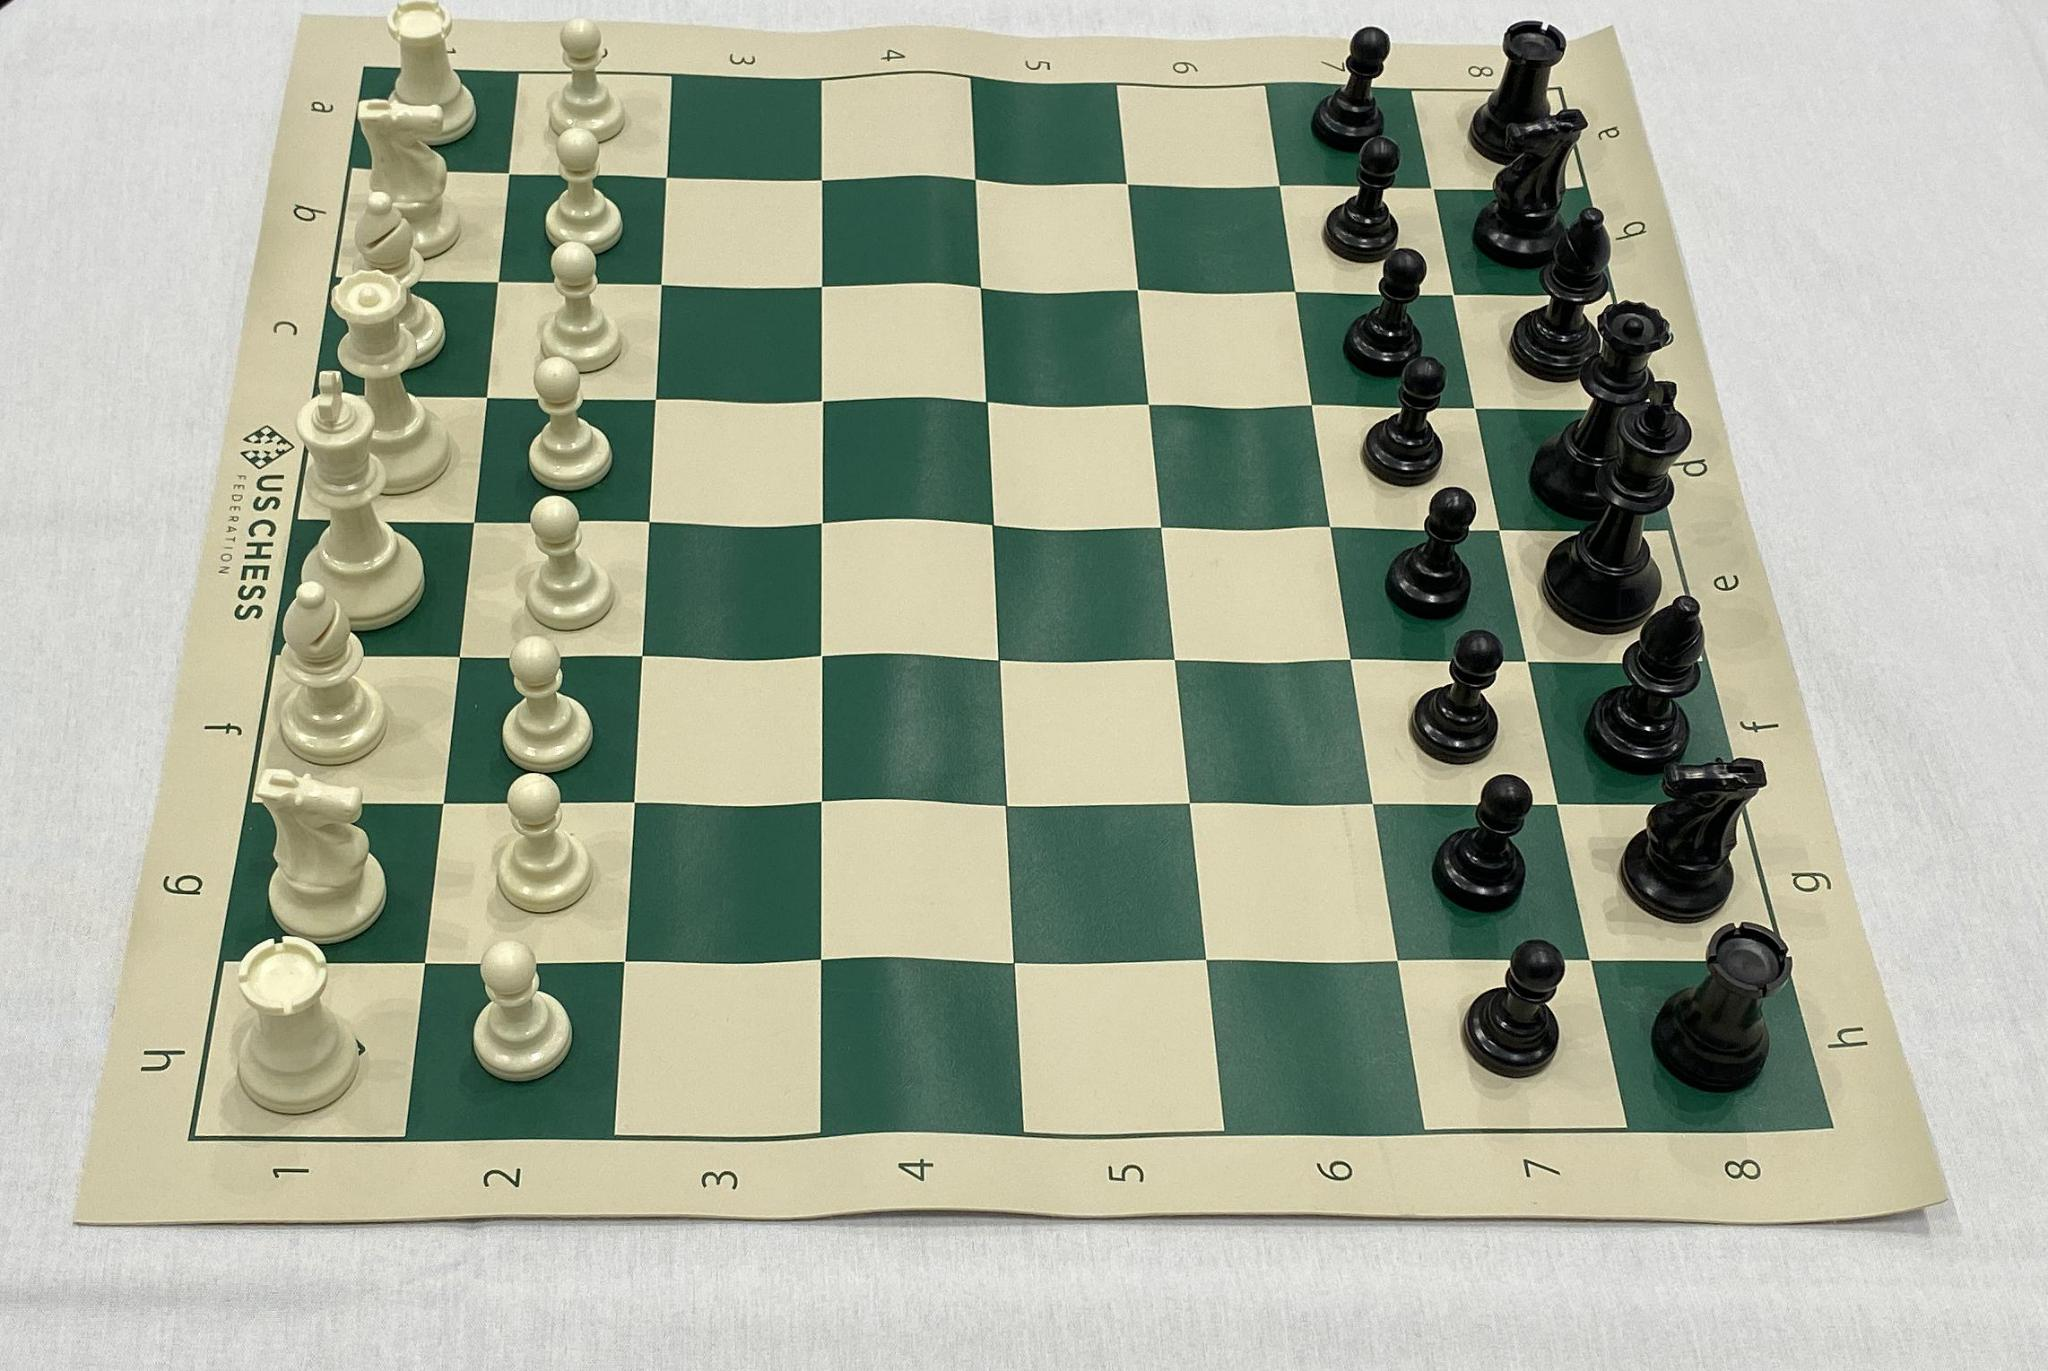

In [21]:
from IPython.display import Image, display

# Correct path to the test image
test_image_path = '/content/dataset/test/images/IMG_0159_JPG.rf.1cf4f243b5072d63e492711720df35f7.jpg'

# Visualize the test image
display(Image(filename=test_image_path))


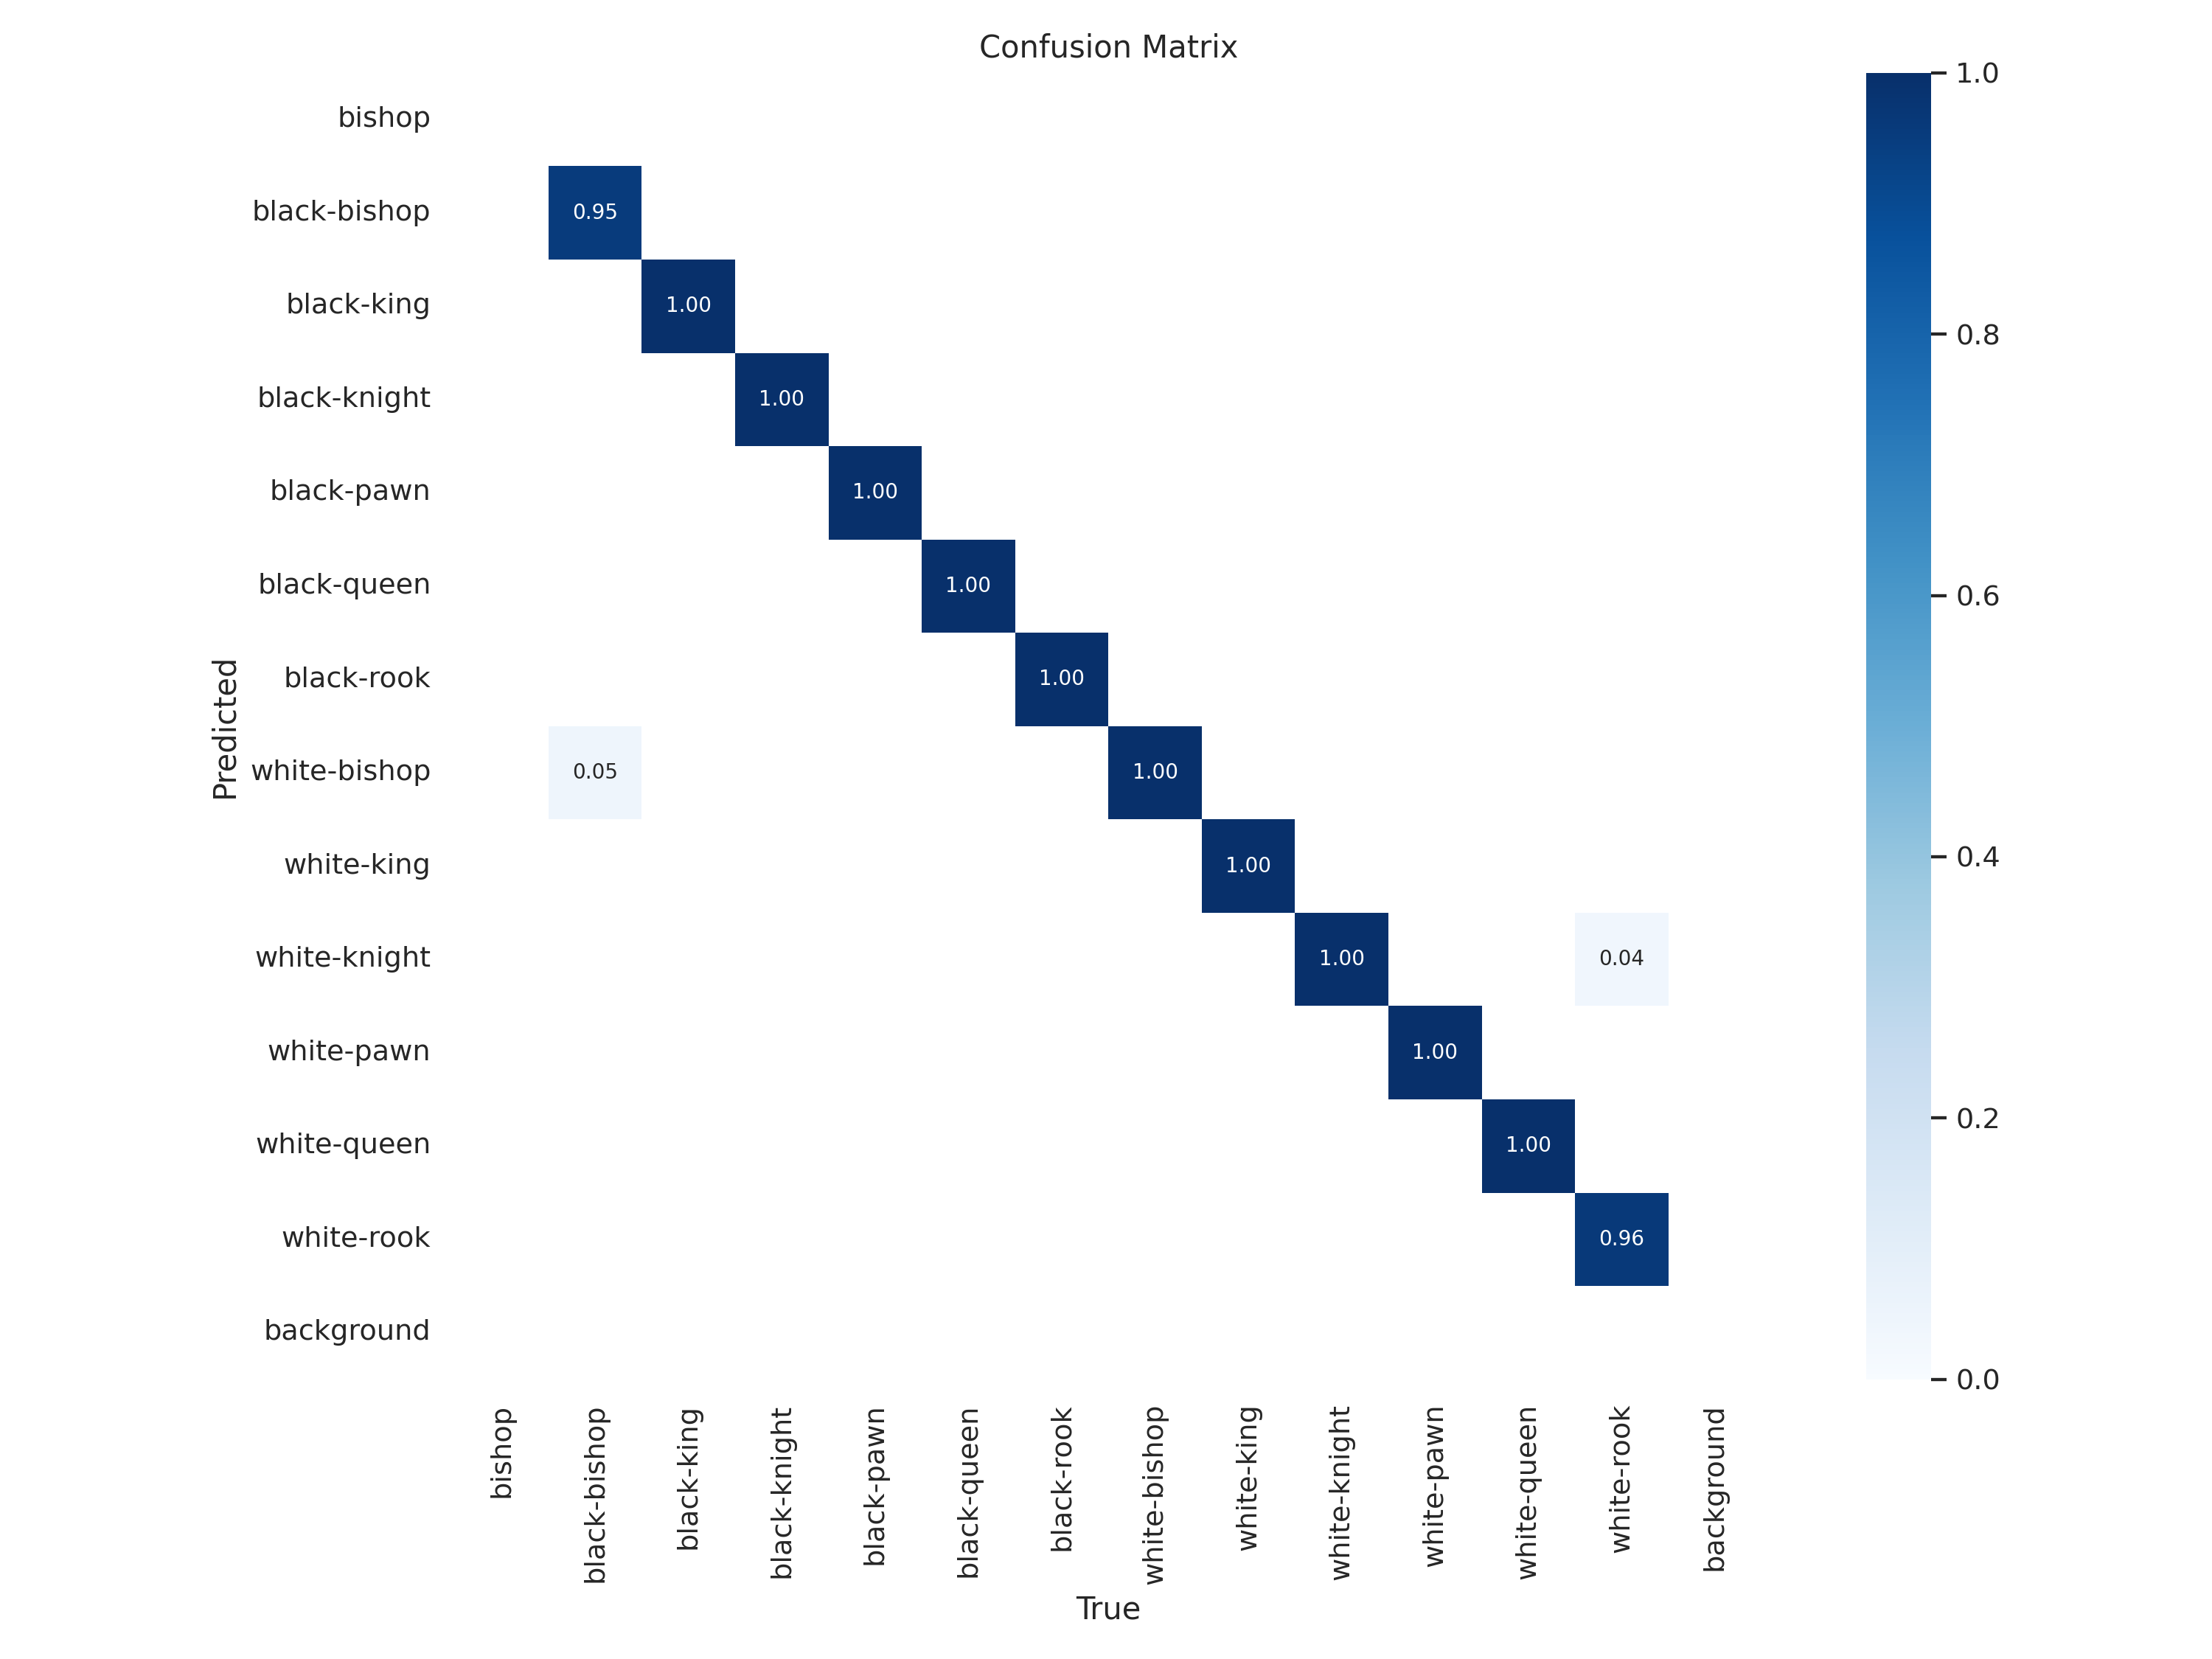

In [25]:
import glob
from IPython.display import Image, display

# Display mAP results (Confusion Matrix)
confusion_matrix_path = "/content/runs/detect/chess_yolov8_model3/confusion_matrix.png"
display(Image(filename=confusion_matrix_path))

# Display sample predictions (First 3 images)
prediction_folder = "/content/runs/detect/chess_yolov8_model/predict/"
for image_path in glob.glob(f"{prediction_folder}*.jpg")[:3]:  # Adjust the path pattern if needed
    display(Image(filename=image_path, width=600))

In [26]:
from google.colab import files

model_path = "/content/runs/detect/chess_yolov8_model3/weights/best.pt"
files.download(model_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>